In [110]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns


In [111]:
df = pd.read_csv('HousingData.csv')

In [112]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [113]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [114]:
df.isna().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [115]:
df.shape

(506, 14)

In [116]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [117]:
df['AGE'].isna().sum()

np.int64(0)

In [118]:
med_col= ['CRIM','INDUS','CHAS','LSTAT']
df[med_col] = df[med_col].fillna(df[med_col].mean())

In [119]:
df.isna().sum()

,0
CRIM,0
ZN,20
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [120]:
df['ZN'] = df['ZN'].fillna(df['ZN'].mean())


In [121]:
df.shape

(506, 14)

In [122]:
df.duplicated().sum()

np.int64(0)

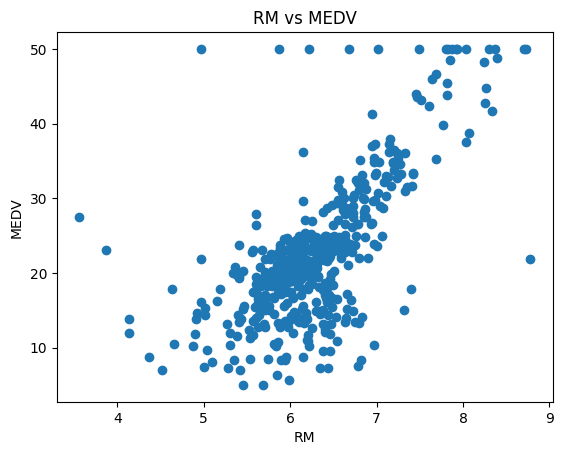

In [123]:
plt.scatter(df['RM'], df['MEDV'])
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.title('RM vs MEDV')
plt.show()


In [124]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [125]:
model = DecisionTreeRegressor(criterion='squared_error', random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [126]:
y_pred = model.predict(X_test)
print("Prediction",y_pred)

Prediction [25.  32.  18.  25.  16.7 22.2 19.3 13.3 21.7 21.2 18.8 16.5  8.8 22.2
 18.2 25.  20.5  7.2 43.8 14.6 22.2 23.7 15.4 22.  12.6 12.6 21.  14.1
 19.5 21.2 18.8 23.1 17.8 15.3 16.7 18.3 33.4 18.7 20.4 24.4 17.5 32.
 43.8 18.2 20.5 17.8 15.4 24.1 23.2 32.5 23.3 34.9 14.3 29.9 45.4 22.7
 13.6 27.9 20.5 19.4 32.  33.  29.4 16.1 28.  18.4 17.8 22.9 28.  14.1
 21.8 30.1  8.3 28.7 23.1  5.6 22.2 43.8 13.3 18.  21.2 16.3 19.4  8.3
 20.3 30.1 14.1 23.1 22.9 18.  21.7  8.4 17.1 17.5 15.3 17.1 50.  16.3
 14.1 16.3 20.7 25. ]


In [127]:
mae = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error",mae)
r2_score = r2_score(y_test,y_pred)
print("R2 Score",r2_score)

Mean Absolute Error 2.6205882352941177
R2 Score 0.8409060560968563


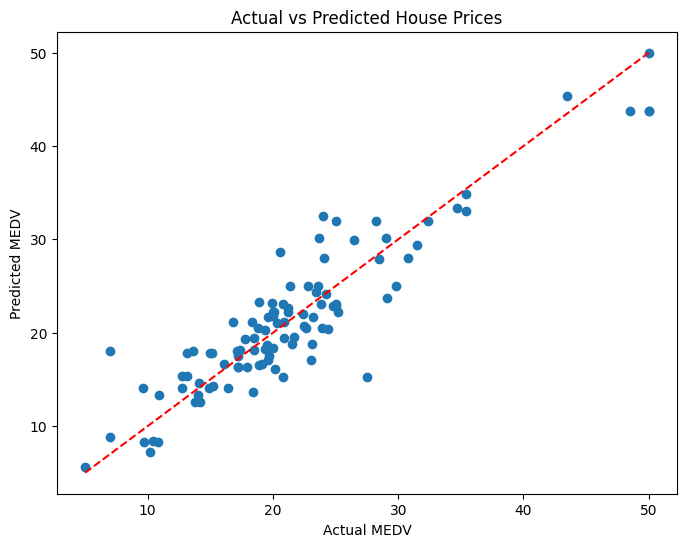

In [128]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [129]:
df.tail(1)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
505,0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88,11.9


In [130]:
model.predict([[0.04741,0.0,11.93,0.0,0.573,6.03,68.518519,2.505,1,273,21.0,396.9,7.88]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([11.9])

In [131]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

result['Difference'] = result['Actual'] - result['Predicted']

print(result.head(20))

     Actual  Predicted  Difference
173    23.6       25.0        -1.4
274    32.4       32.0         0.4
491    13.6       18.0        -4.4
72     22.8       25.0        -2.2
452    16.1       16.7        -0.6
76     20.0       22.2        -2.2
316    17.8       19.3        -1.5
140    14.0       13.3         0.7
471    19.6       21.7        -2.1
500    16.8       21.2        -4.4
218    21.5       18.8         2.7
9      18.9       16.5         2.4
414     7.0        8.8        -1.8
78     21.2       22.2        -1.0
323    18.5       18.2         0.3
473    29.8       25.0         4.8
124    18.8       20.5        -1.7
388    10.2        7.2         3.0
195    50.0       43.8         6.2
448    14.1       14.6        -0.5


In [132]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train R2:", train_score)
print("Test R2:", test_score)

Train R2: 1.0
Test R2: 0.8409060560968563


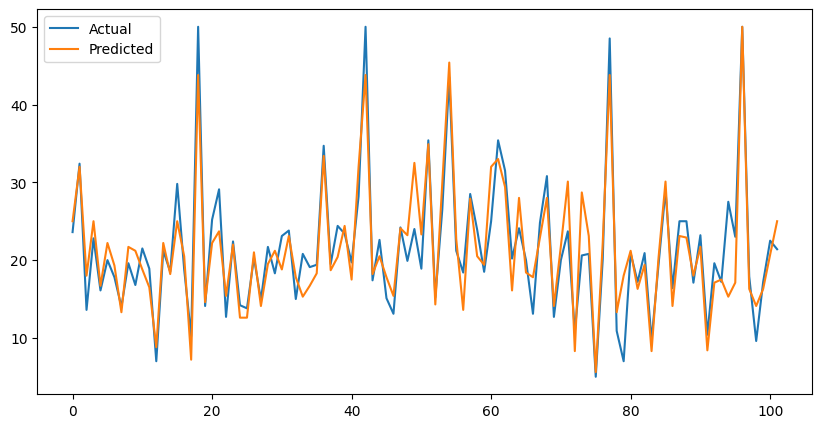

In [133]:
plt.figure(figsize=(10,5))
plt.plot(range(len(y_test)), y_test.values, label='Actual')
plt.plot(range(len(y_pred)), y_pred, label='Predicted')

plt.legend()
plt.show()